# Etapa 1: simulación básica con álbum reducido
Ale Sierra #24405 y Camila Sandoval #24358

RESULTADOS DE LA SIMULACIÓN

Número de simulaciones: 10000
Número total de estampas (N): 100
Estampas por sobre (S): 7

--- Sobres necesarios ---
Media: 72.2456
Desviación estándar: 17.4715

--- Estampas repetidas ---
Media: 405.7192
Desviación estándar: 122.3006

--- Probabilidad ---
P(necesitar más de 30 sobres): 1.0000

--- Resultados teóricos ---
H_100 = 5.187378
E[T] teórico ≈ 74.1054
Mínimo teórico de sobres: 15


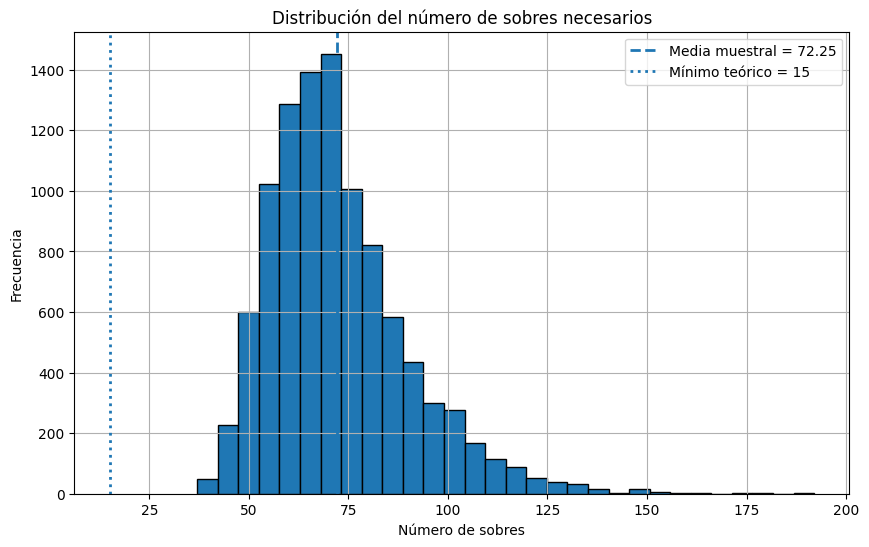

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parámetros de simulación
# -------------------------
N = 100       # número total de estampas diferentes
S = 7         # estampas por sobre
R = 10000     # número de simulaciones

SEMILLA = 2026
np.random.seed(SEMILLA)

# ---------------------------------------------------------
# Arreglos para almacenar resultados de cada simulación
# ---------------------------------------------------------
sobres_totales = []
repetidas_totales = []

# =========================================================
# Simulación Monte Carlo
# =========================================================

for _ in range(R):

    # Conjunto de estampas obtenidas
    album = np.zeros(N, dtype=bool)

    # Contadores
    sobres = 0
    repetidas = 0
    unicas_obtenidas = 0

    # Continuar hasta completar el álbum
    while unicas_obtenidas < N:

        sobres += 1

        # Generar S estampas distintas dentro del mismo sobre
        sobre_actual = np.random.choice(N, size=S, replace=False)

        # Revisar cada estampa del sobre
        for estampa in sobre_actual:

            if album[estampa]:
                repetidas += 1
            else:
                album[estampa] = True
                unicas_obtenidas += 1

    # Guardar resultados
    sobres_totales.append(sobres)
    repetidas_totales.append(repetidas)

# Convertir a arrays numpy
sobres_totales = np.array(sobres_totales)
repetidas_totales = np.array(repetidas_totales)

# =========================================================
# Estadísticas empíricas
# =========================================================

media_sobres = np.mean(sobres_totales)
std_sobres = np.std(sobres_totales)

media_repetidas = np.mean(repetidas_totales)
std_repetidas = np.std(repetidas_totales)

# Probabilidad de necesitar más de 30 sobres
prob_mas_30 = np.mean(sobres_totales > 30)

# =========================================================
# Teoría del coleccionista
# E[T] ≈ (N/S) * H_N
# =========================================================

H_N = np.sum(1 / np.arange(1, N + 1))

esperado_teorico = (N / S) * H_N

# Número mínimo teórico de sobres (sin repetidas)
minimo_teorico = int(np.ceil(N / S))

# =========================================================
# Resultados
# =========================================================

print("=" * 60)
print("RESULTADOS DE LA SIMULACIÓN")
print("=" * 60)

print(f"\nNúmero de simulaciones: {R}")
print(f"Número total de estampas (N): {N}")
print(f"Estampas por sobre (S): {S}")

print("\n--- Sobres necesarios ---")
print(f"Media: {media_sobres:.4f}")
print(f"Desviación estándar: {std_sobres:.4f}")

print("\n--- Estampas repetidas ---")
print(f"Media: {media_repetidas:.4f}")
print(f"Desviación estándar: {std_repetidas:.4f}")

print("\n--- Probabilidad ---")
print(f"P(necesitar más de 30 sobres): {prob_mas_30:.4f}")

print("\n--- Resultados teóricos ---")
print(f"H_{N} = {H_N:.6f}")
print(f"E[T] teórico ≈ {esperado_teorico:.4f}")
print(f"Mínimo teórico de sobres: {minimo_teorico}")

# =========================================================
# Visualización
# =========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    sobres_totales,
    bins=30,
    edgecolor='black'
)

# Línea de media muestral
plt.axvline(
    media_sobres,
    linestyle='--',
    linewidth=2,
    label=f'Media muestral = {media_sobres:.2f}'
)

# Línea del mínimo teórico
plt.axvline(
    minimo_teorico,
    linestyle=':',
    linewidth=2,
    label=f'Mínimo teórico = {minimo_teorico}'
)

plt.title('Distribución del número de sobres necesarios')
plt.xlabel('Número de sobres')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)

plt.show()

# Preguntas de análisis:

## 1. Número mínimo de sobres

El mínimo teórico de sobres ocurre si no salen estampas repetidas.

mínimo = 100 / 7 = 14.28

Como no se pueden comprar fracciones de sobres, se necesitan 15 sobres.

En las simulaciones normalmente no aparece este caso porque siempre salen estampas repetidas.

---

## 2. Valor esperado teórico de sobres

La teoría del coleccionista usa:

E[T] ≈ (N / S) * H_N

Con:

H_100 ≈ 5.1874

Entonces:

E[T] ≈ (100 / 7) * 5.1874 ≈ 74.11

La media de la simulación debería ser cercana a 74 sobres.

---

## 3. Número esperado de repetidas

Si se esperan aproximadamente 74.11 sobres y cada sobre tiene 7 estampas:

74.11 * 7 ≈ 518.77 estampas totales

Como solo 100 son distintas:

518.77 - 100 ≈ 418.77

Por lo tanto, el número esperado de repetidas es aproximadamente 419.

---

## 4. Interpretación de la desviación estándar

La desviación estándar indica cuánto varía el número de sobres entre simulaciones.

Sí es relativamente grande, porque las últimas estampas son difíciles de conseguir y pueden tardar muchos sobres en aparecer. Por eso algunas simulaciones terminan mucho más rápido o más lento que otras.

# Etapa 2: Análisis de la probabilidad de éxito en función del número de sobres

In [2]:
# -------------------------
# Parámetros del problema
# -------------------------
N = 100      # número total de estampas diferentes
S = 7        # estampas por sobre

# Cantidades de sobres a evaluar
M_values = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

# Número de simulaciones por cada M
R = 10000

# -------------------------
# Función de simulación
# -------------------------
def completar_album(M, N, S):
    album = set()

    for _ in range(M):
        sobre = np.random.randint(1, N + 1, S)
        album.update(sobre)

    # Verificar si el álbum está completo
    if len(album) == N:
        return 1
    else:
        return 0
    

# -------------------------
# Simulación principal
# -------------------------
probabilidades = []

for M in M_values:
    exitos = 0

    for _ in range(R):
        exitos += completar_album(M, N, S)

    probabilidad = exitos / R
    probabilidades.append(probabilidad)

    print(f"M = {M:2d} sobres -> Probabilidad estimada = {probabilidad:.4f}")

# -------------------------
# Tabla de resultados
# -------------------------
print("\nTabla de probabilidades estimadas")
print("-" * 40)
print("Sobres (M) | Probabilidad")
print("-" * 40)

for M, p in zip(M_values, probabilidades):
    print(f"{M:^11} | {p:.4f}")

M = 20 sobres -> Probabilidad estimada = 0.0000
M = 25 sobres -> Probabilidad estimada = 0.0000
M = 30 sobres -> Probabilidad estimada = 0.0000
M = 35 sobres -> Probabilidad estimada = 0.0003
M = 40 sobres -> Probabilidad estimada = 0.0005
M = 45 sobres -> Probabilidad estimada = 0.0095
M = 50 sobres -> Probabilidad estimada = 0.0387
M = 60 sobres -> Probabilidad estimada = 0.2149
M = 70 sobres -> Probabilidad estimada = 0.4755
M = 80 sobres -> Probabilidad estimada = 0.6927

Tabla de probabilidades estimadas
----------------------------------------
Sobres (M) | Probabilidad
----------------------------------------
    20      | 0.0000
    25      | 0.0000
    30      | 0.0000
    35      | 0.0003
    40      | 0.0005
    45      | 0.0095
    50      | 0.0387
    60      | 0.2149
    70      | 0.4755
    80      | 0.6927


## Visualización

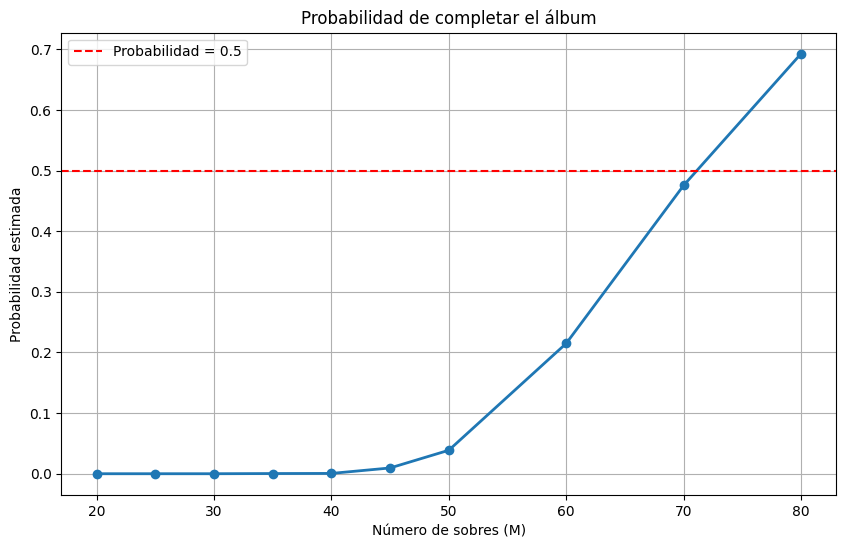

In [4]:
# -------------------------
# Gráfica de resultados
# -------------------------
plt.figure(figsize=(10,6))

plt.plot(M_values, probabilidades,
         marker='o', linewidth=2)

# Línea horizontal en 50%
plt.axhline(0.5,
            color='red',
            linestyle='--',
            label='Probabilidad = 0.5')

plt.xlabel('Número de sobres (M)')
plt.ylabel('Probabilidad estimada')
plt.title('Probabilidad de completar el álbum')
plt.grid(True)
plt.legend()

plt.show()

## Preguntas de análisis

### Pregunta 1: ¿Para qué valor de M la probabildiad estimada supera por primera vez el 50%? ¿Y el 90%?

In [5]:
# -------------------------
# Pregunta 1
# -------------------------
M_50 = None
M_90 = None

for M, p in zip(M_values, probabilidades):

    if M_50 is None and p >= 0.5:
        M_50 = M

    if M_90 is None and p >= 0.9:
        M_90 = M

print(f"Primer M con probabilidad >= 50%: {M_50}")
print(f"Primer M con probabilidad >= 90%: {M_90}")

Primer M con probabilidad >= 50%: 80
Primer M con probabilidad >= 90%: None


### Respuesta — Pregunta 1

La probabilidad estimada supera por primera vez el 50% cuando:

- **M = 80 sobres**

La probabilidad nunca supera el 90% dentro de los valores evaluados, por lo que:

- **No se alcanzó una probabilidad del 90%**

Esto indica que incluso comprando 80 sobres todavía es relativamente difícil completar el álbum debido a la gran cantidad de estampas diferentes y a la presencia de repetidas.

### Pregunta 2: Comparación con etapa 1

In [12]:
# -------------------------
# Pregunta 2
# -------------------------
print("Comparación con la etapa 1")
print("-" * 40)

print(f"Valor de M con probabilidad >= 50%: {M_50}")


Comparación con la etapa 1
----------------------------------------
Valor de M con probabilidad >= 50%: 80


### Respuesta — Pregunta 2

El valor de \( M \) donde la probabilidad supera el 50% fue:

- **M = 80 sobres**

Este valor debería ser similar a la mediana obtenida en la etapa 1, ya que la mediana representa el punto donde aproximadamente:

- el 50% de las simulaciones completan el álbum antes,
- y el otro 50% después.

Por ello, ambos resultados están relacionados y describen el comportamiento típico del número de sobres necesarios para completar el álbum.

### Pregunta 3: Teoría del coleccionista

In [9]:
# -------------------------
# Pregunta 3
# -------------------------
M = 50

# Cota teórica
cota_fallar = N * np.exp(-(M * S) / N)

# Cota para completar
cota_exito = 1 - cota_fallar

print(f"Cota superior de fallar: {cota_fallar:.4f}")
print(f"Cota inferior de éxito: {cota_exito:.4f}")


Cota superior de fallar: 3.0197
Cota inferior de éxito: -2.0197


In [11]:

# -------------------------
# Comparación experimental
# -------------------------
indice_50 = M_values.index(50)
prob_simulada = probabilidades[indice_50]

print(f"Probabilidad simulada para M = 50: {prob_simulada:.4f}")
print(f"Cota teórica de éxito: {cota_exito:.4f}")

Probabilidad simulada para M = 50: 0.0387
Cota teórica de éxito: -2.0197


### Respuesta — Pregunta 3

Para \( M = 50 \) sobres, la cota teórica obtenida fue:

- Cota superior de fallar: \( 3.0197 \)
- Cota inferior de éxito: \( -2.0197 \)

La probabilidad simulada experimentalmente fue:

- \( 0.0387 \)

La cota teórica obtenida no es útil en este caso porque la probabilidad de éxito no puede ser negativa. Esto ocurre debido a que la desigualdad utilizada produce una aproximación demasiado débil para valores pequeños de \( M \).

Sin embargo, la teoría sigue siendo importante porque permite entender cómo se comporta el problema del coleccionista y cómo crece la probabilidad de completar el álbum a medida que aumenta el número de sobres.